# 🐬 bluer-swallow steering setpoint

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from typing import Tuple

from bluer_options import string

from bluer_ugv.host import signature
from bluer_ugv.swallow.session.classical.setpoint.steering import generate_left_and_right
from bluer_ugv.tests.test_classical_setpoint_steering import test_cases
from bluer_ugv.logger import logger

logger.info(f"{'.'.join(signature())},\nbuilt on {string.pretty_date()}")

🐬  bluer_ugv-6.730.1.bluer_sbc-8.177.1.bluer_ai-12.257.1.bluer_objects-6.252.1.bluer_options-5.164.1.torch-2.2.2.Python 3.12.9.Darwin 23.6.0..Jupyter-Notebook,
built on 31 August 2025, 10:52:13


---

# test cases

In [2]:
for test_case in test_cases:
    test_case[2], test_case[3] = generate_left_and_right(
        speed=test_case[0], 
        steering=test_case[1],
    )

print(test_cases)

[[0, 0, 0, 0], [0, 50, 50, -50], [0, -50, -50, 50], [50, 0, 50, 50], [-50, 0, -50, -50], [50, 50, 100, 0], [50, -50, 0, 100], [-50, 50, 0, -100], [-50, -50, -100, 0]]


# visualization

In [3]:
# image size
res = 200
img = np.zeros((res, res, 3), dtype=np.uint8)

# map -100..100 to 0..199
for i in trange(res):
    for j in range(res):
        speed = (j / (res - 1)) * 200 - 100
        steering = (i / (res - 1)) * 200 - 100
        left, right = generate_left_and_right(speed, steering)
        
        # normalize to 0..255, using left=green, right=blue
        g = int((left + 100) / 200 * 255)
        b = int((right + 100) / 200 * 255)
        img[res-1-i, j] = (0, g, b)

100%|██████████| 200/200 [00:00<00:00, 3926.57it/s]


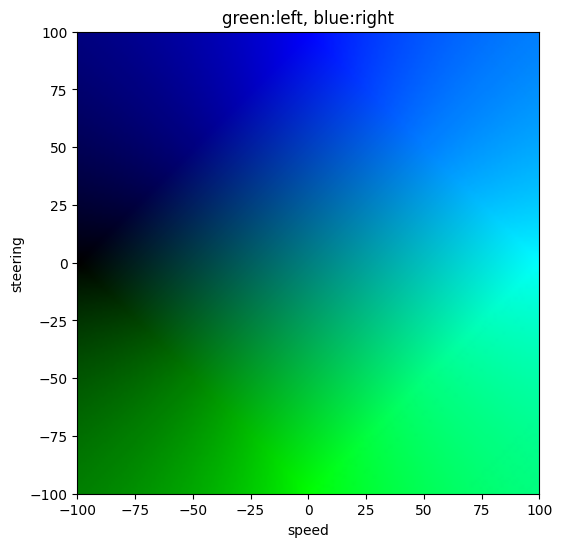

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, extent=[-100,100,-100,100], origin="lower")
ax.set_xlabel("speed")
ax.set_ylabel("steering")
plt.title("green:left, blue:right")
plt.show()

---

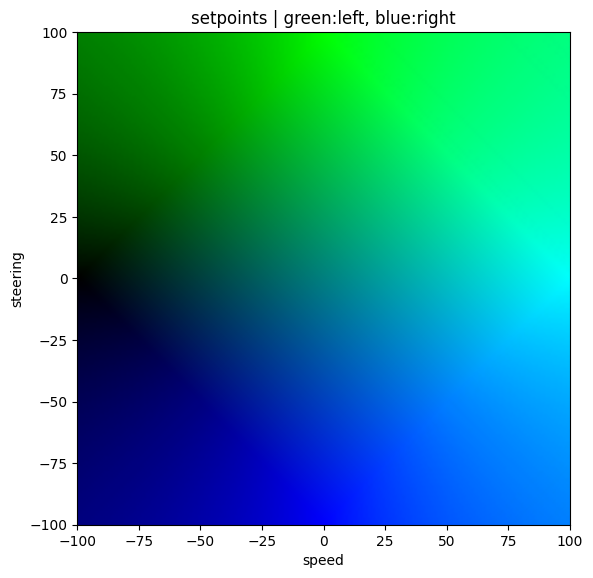

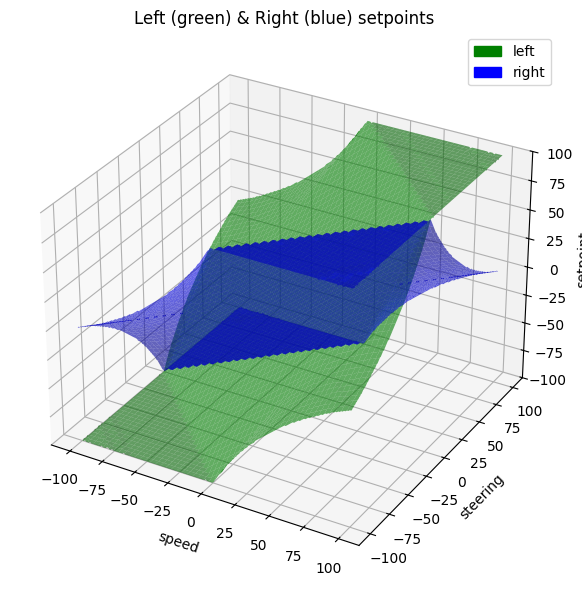

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# --- config ---
res = 200
speed_vals    = np.linspace(-100, 100, res)
steering_vals = np.linspace(-100, 100, res)

SPEED, STEER = np.meshgrid(speed_vals, steering_vals)

# vectorize your function
vfunc = np.vectorize(generate_left_and_right, otypes=[float, float])
LEFT, RIGHT = vfunc(SPEED, STEER)

# --- 2D image (green=left, blue=right) ---
g = np.clip(((LEFT  + 100) / 200) * 255, 0, 255).astype(np.uint8)
b = np.clip(((RIGHT + 100) / 200) * 255, 0, 255).astype(np.uint8)
img = np.dstack([np.zeros_like(g), g, b])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, extent=[-100, 100, -100, 100], origin="lower")
ax.set_xlabel("speed")
ax.set_ylabel("steering")
ax.set_title("setpoints | green:left, blue:right")
plt.tight_layout()
plt.show()

# --- 3D plot with both LEFT and RIGHT ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# plot LEFT surface (green)
ax.plot_surface(SPEED, STEER, LEFT, color="green", alpha=0.6, label="left")

# plot RIGHT surface (blue)
ax.plot_surface(SPEED, STEER, RIGHT, color="blue", alpha=0.6, label="right")

ax.set_xlabel("speed")
ax.set_ylabel("steering")
ax.set_zlabel("setpoint")
ax.set_title("Left (green) & Right (blue) setpoints")
ax.set_zlim(-100, 100)

# hack: matplotlib doesn’t auto-legend plot_surface, so add proxies
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="green", label="left"),
    Patch(color="blue", label="right")
])

plt.tight_layout()
plt.show()

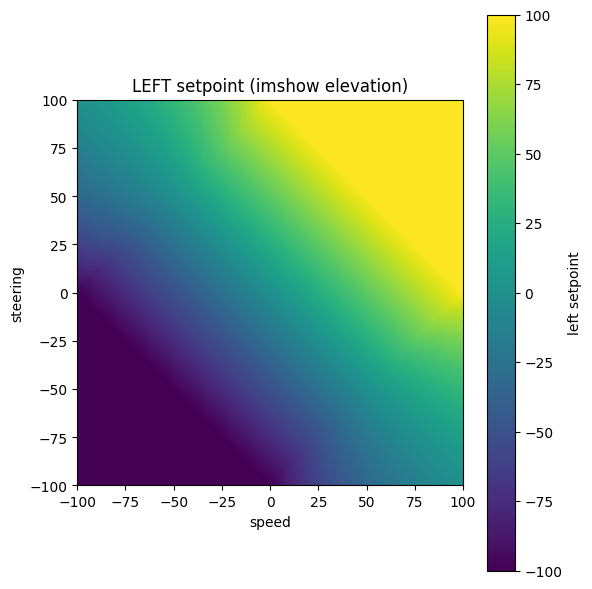

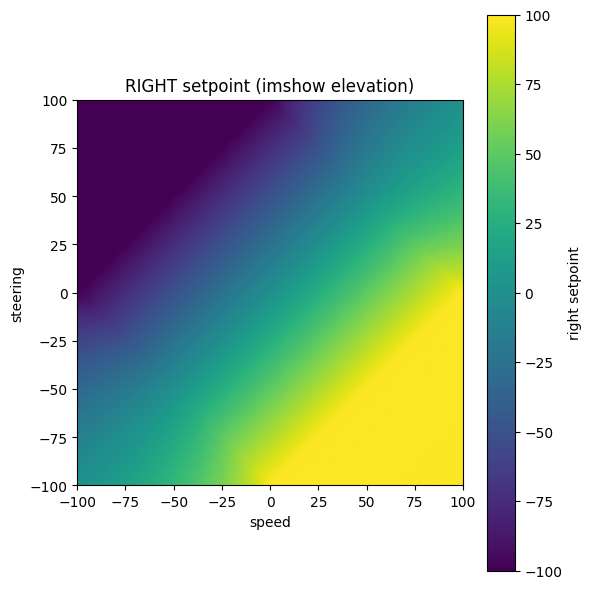

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- config ---
res = 200
speed_vals    = np.linspace(-100, 100, res)
steering_vals = np.linspace(-100, 100, res)
SPEED, STEER  = np.meshgrid(speed_vals, steering_vals)

# Vectorize your function to handle arrays
vfunc = np.vectorize(generate_left_and_right, otypes=[float, float])
LEFT, RIGHT = vfunc(SPEED, STEER)

# (optional) keep values in expected range for consistent color scaling
LEFT  = np.clip(LEFT,  -100, 100)
RIGHT = np.clip(RIGHT, -100, 100)

# --- LEFT heatmap ---
fig1, ax1 = plt.subplots(figsize=(6, 6))
im1 = ax1.imshow(
    LEFT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,          # same scale for both plots
    interpolation="nearest"       # crisp pixels
    # cmap=...                   # optionally set e.g., "viridis" or "coolwarm"
)
ax1.set_xlabel("speed")
ax1.set_ylabel("steering")
ax1.set_title("LEFT setpoint (imshow elevation)")
plt.colorbar(im1, ax=ax1, label="left setpoint")
plt.tight_layout()
plt.show()

# --- RIGHT heatmap ---
fig2, ax2 = plt.subplots(figsize=(6, 6))
im2 = ax2.imshow(
    RIGHT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,
    interpolation="nearest"
    # cmap=...                   # optionally set a different colormap if you want
)
ax2.set_xlabel("speed")
ax2.set_ylabel("steering")
ax2.set_title("RIGHT setpoint (imshow elevation)")
plt.colorbar(im2, ax=ax2, label="right setpoint")
plt.tight_layout()
plt.show()


/var/folders/zt/yvc9hx9x3txdbl3ny6bfz6qr0000gn/T/ipykernel_70002/61576654.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


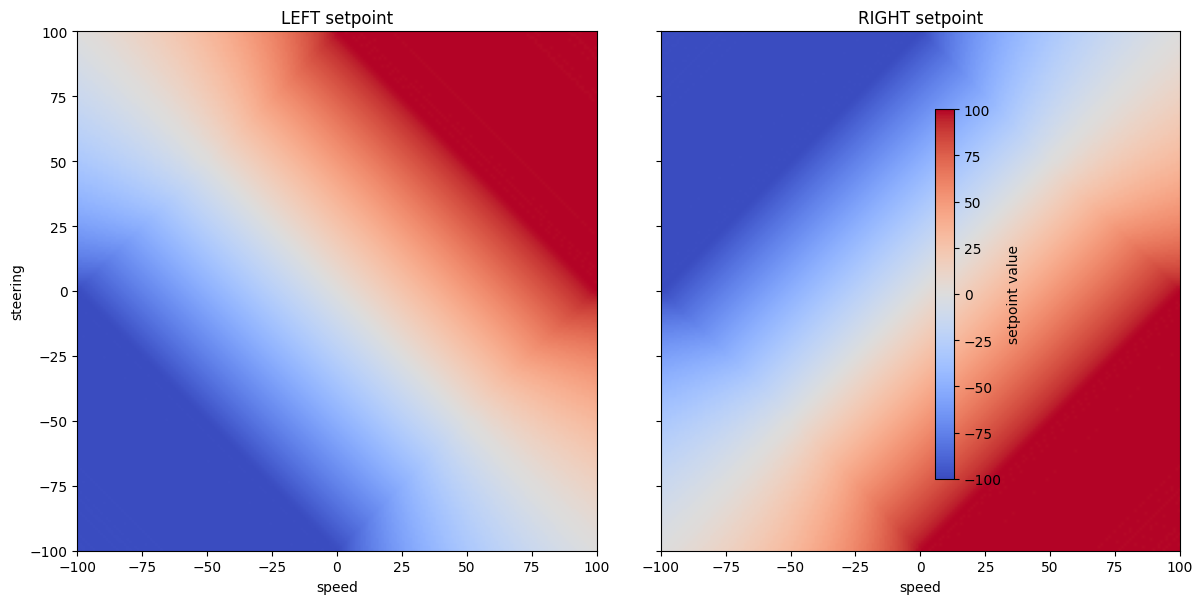

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- config ---
res = 200
speed_vals    = np.linspace(-100, 100, res)
steering_vals = np.linspace(-100, 100, res)
SPEED, STEER  = np.meshgrid(speed_vals, steering_vals)

# Vectorize your function to handle arrays
vfunc = np.vectorize(generate_left_and_right, otypes=[float, float])
LEFT, RIGHT = vfunc(SPEED, STEER)

# clip to [-100,100] for consistent scale
LEFT  = np.clip(LEFT,  -100, 100)
RIGHT = np.clip(RIGHT, -100, 100)

# --- plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# LEFT
im1 = ax1.imshow(
    LEFT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,
    cmap="coolwarm"   # diverging cmap is good for positive/negative contrast
)
ax1.set_title("LEFT setpoint")
ax1.set_xlabel("speed")
ax1.set_ylabel("steering")

# RIGHT
im2 = ax2.imshow(
    RIGHT,
    extent=[speed_vals.min(), speed_vals.max(), steering_vals.min(), steering_vals.max()],
    origin="lower",
    vmin=-100, vmax=100,
    cmap="coolwarm"
)
ax2.set_title("RIGHT setpoint")
ax2.set_xlabel("speed")

# one shared colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.8, pad=0.05)
cbar.set_label("setpoint value")

plt.tight_layout()
plt.show()


---

In [5]:
# END